# Active Brownian Particle Systems

## Overview

### Questions

* How can we model particles with self-induced **active forces**?
* What types of phase diagrams can we encounter when investigating **non-equilibrium** systems?

### Objectives

* Write an **MD simulation** for spherical **active** particles using the **Active Brownian Particle (ABP) model** 
* Learn how to implement a **Brownian integrator** at kT = 0 with **rotational diffusion** to intialize and thermalize and active particle system that we can then visualize.


## Boilerplate Code

In [1]:
import hoomd
import itertools

import gsd.hoomd

import numpy as np

In [2]:
import os

fn = os.path.join(os.getcwd(), "lattice.gsd")
![ -e "$fn" ] && rm "$fn"
fn = os.path.join(os.getcwd(), "active.gsd")
![ -e "$fn" ] && rm "$fn"

The `render` function in the next (hidden) cell will render a snapshot using **fresnel**. Find the source in the [hoomd-examples](https://github.com/glotzerlab/hoomd-examples) repository.

In [3]:
# This is not intended as a full tutorial on fresnel - see the fresnel user
# documentation (https://fresnel.readthedocs.io/) if you would like to learn more.

import warnings

import fresnel
import IPython
import packaging.version

device = fresnel.Device()
tracer = fresnel.tracer.Path(device=device, w=300, h=300)

FRESNEL_MIN_VERSION = packaging.version.parse("0.13.0")
FRESNEL_MAX_VERSION = packaging.version.parse("0.14.0")


def render(snapshot):
    if ('version' not in dir(fresnel) or packaging.version.parse(
            fresnel.version.version) < FRESNEL_MIN_VERSION
            or packaging.version.parse(
                fresnel.version.version) >= FRESNEL_MAX_VERSION):
        warnings.warn(
            f"Unsupported fresnel version {fresnel.version.version} - expect errors."
        )
    central_color = fresnel.color.linear([252 / 255, 41 / 255, 0 / 255])

    L = snapshot.configuration.box[0]
    scene = fresnel.Scene(device)
    geometry = fresnel.geometry.Sphere(scene,
                                       N=len(snapshot.particles.position),
                                       radius=0.5)
    geometry.material = fresnel.material.Material(color=[0, 0, 0],
                                                  roughness=0.5,
                                                  primitive_color_mix=1.0)
    geometry.position[:] = snapshot.particles.position[:]
    geometry.color[snapshot.particles.typeid[:] == 0] = central_color
    geometry.radius[snapshot.particles.typeid[:] == 0] = 0.3
    geometry.outline_width = 0.04
    box = fresnel.geometry.Box(scene, [L, L, L, 0, 0, 0], box_radius=.02)

    scene.lights = [
        fresnel.light.Light(direction=(0, 0, 1),
                            color=(0.8, 0.8, 0.8),
                            theta=np.pi),
        fresnel.light.Light(direction=(1, 1, 1),
                            color=(1.1, 1.1, 1.1),
                            theta=np.pi / 3)
    ]
    scene.camera = fresnel.camera.Orthographic(position=(0, 0, L * 2),
                                               look_at=(0, 0, 0),
                                               up=(0, 1, 0),
                                               height=L * 1.1)
    scene.background_alpha = 1
    scene.background_color = (1, 1, 1)
    return IPython.display.Image(tracer.sample(scene, samples=500)._repr_png_())

## Simulating Brownian Active Particles

In this part of the tutorial, we will create a simulation of **self-propelled** active particles using the **Active Brownian Particle (ABP) model**. As mentioned in part 1 of this tutorial, we can set up the initial state of the simulation in a very similar manner to previous methods we have used in [earlier hoomd MD simulation tutorials](../01-Introducing-Molecular-Dynamics/00-index.ipynb). 

## Set up the Simulation

We will first initialize a system of spherical particles with a given particle density, in an array. We save an initial snapshot of the current state of the system.

In [4]:
rho = 0.3 # particle area density
simseed = 1

m = 10
N_particles = m**2
K = np.ceil(N_particles ** (1 / 2))
L = (N_particles / rho)**(1 / 2)
spacing = L / K
x = np.linspace(-L / 2, L / 2, int(K), endpoint=False)

position_2D = np.array(list(itertools.product(x, repeat=2))) + [spacing / 2, spacing / 2]
position_3D = np.hstack([position_2D[:N_particles], np.zeros((N_particles, 1))])

frame = gsd.hoomd.Frame()
frame.particles.N = N_particles
frame.particles.position = position_3D[0:N_particles, :]
frame.particles.typeid = [0] * N_particles
frame.configuration.box = [L, L, 0, 0, 0, 0,]
frame.particles.types = ['A']
frame.particles.mass = [1] * N_particles
frame.particles.orientation = [[1, 0, 0, 0]] * N_particles

with gsd.hoomd.open(name='lattice.gsd', mode='w') as f:
    f.append(frame)

Configure this simulation to run on CPU from this snapshot as we have in previous tutorials. If the box is correctly set to simulate in 2D, hoomd.Box.is2D will be True.

True. Lz = 0 in the simulation box.


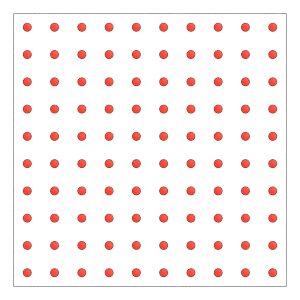

In [5]:
cpu = hoomd.device.CPU()
sim = hoomd.Simulation(device=cpu, seed=simseed)
state = sim.create_state_from_gsd(filename='lattice.gsd')

if hoomd.Box.is2D:
    print('True. Lz = 0 in the simulation box.')
    
render(sim.state.get_snapshot())

## Defining Interactions in an Active Particle system

This simulation uses overdamped Viscous dynamics with a drag force set by gamma. Add the Overdamped Viscous dynamics method to our integrator.

In [6]:
kT = 0
gamma = 1

filter_all = hoomd.filter.All()
overdamped = hoomd.md.methods.OverdampedViscous(filter=filter_all)
overdamped.gamma.default = gamma
overdamped.gamma_r.default = [gamma,gamma,gamma]

integrator = hoomd.md.Integrator(dt=0.001, integrate_rotational_dof=False)
sim.operations.integrator = integrator
integrator.methods.append(overdamped)

**Péclet number (Pe)** is a commonly used dimmensionless measure that quantifies advective and diffusive transport in a system. As such, the Péclet number is a desirable parameter to control in active particle simulations. Pe relates to the active force on a particle as: 

F_A = Pe*kT/sigma

or 
Pe = v*a/D

gamma = D_rot a^2 /D

## TO DO: Talk to Philipp


Thus, to control

In [7]:
activity = 0.3
rotational_diffusion = 0.1

active = hoomd.md.force.Active(filter=filter_all)
active.active_force['A'] = (activity,0,0)
active.active_torque['A'] = (0,0,0)

integrator.forces.append(active)

rotational_diffusion_updater = active.create_diffusion_updater(
    trigger=1, rotational_diffusion = 0.1)
sim.operations += rotational_diffusion_updater

Run the Simulation and get initial snapshot.

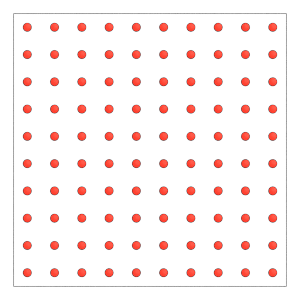

In [8]:
logger = hoomd.logging.Logger(['particle','constraint'])
gsd_oper = hoomd.write.GSD(trigger=hoomd.trigger.Periodic(int(100)), filename='active.gsd',logger=logger,mode='wb',dynamic=['momentum','property'],filter=hoomd.filter.All())

sim.operations += gsd_oper

sim.state.thermalize_particle_momenta(filter=filter_all, kT=kT)
sim.run(0)
render(sim.state.get_snapshot())

Thermalize the system

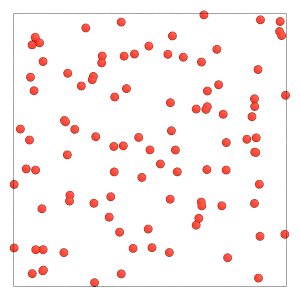

In [9]:
sim.run(10000)
gsd_oper.flush()
render(sim.state.get_snapshot())

In [2]:
sim.state

NameError: name 'sim' is not defined

In this tutorial, we have successfully placed active self-propelled particles in a non-equilibrium MD simulation. However, here, it is difficult to by inspecting this system by eye that the particles are driven by an active propulsion force. In some other active systems the collective effect of the active propulsion is slightly easier to see. 

In the [next tutorial](03-Motility-Induced-Phase-Separation-In-2D.ipynb), we will explore one such system: a 2D system of purely repulsive active particles that exhibit gas-liquid coexistance at intermediate densities. This phenomenon is known as **motility induced phase separation (MIPS)**.